In [ ]:
from pathlib import Path

folder = Path("/mnt/data/datasets/Сравнение чертежей/Эскизы датасет")
files = sorted(folder.glob("*.jpg"))

for i, file in enumerate(files):
    print(f"[{i}] {file.stem}")

In [ ]:
IDX = 5

In [ ]:
import cv2

src = cv2.imread(str(files[IDX]), cv2.IMREAD_COLOR_BGR)

In [ ]:
# for i, f in enumerate(files):
#     W, H = src.shape[1], src.shape[0]
#     w_mm, h_mm = (297, 210) if W > H else (210, 297)
#     dx, dy = W / (w_mm / 25.4), H / (h_mm / 25.4)
#     print(f"[{i:2d}] {f.stem:>3} {W:5d}x{H:4d} ar={W / H:.3f} dx={dx:6.1f} dy={dy:6.1f} dx/dy={dx / dy:.3f}")


In [ ]:
import numpy as np

# https://raw.githubusercontent.com/PaddlePaddle/PaddleOCR/main/ppocr/data/imaug/operators.py


def preprocess_detector(src_bgr: np.ndarray, limit_size: int = 2400) -> tuple[np.ndarray, float, float]:
    h, w = src_bgr.shape[:2]
    ratio = float(limit_size) / max(h, w)

    mean = np.array([0.485, 0.456, 0.406], np.float32).reshape(1, 1, 3)
    std = np.array([0.229, 0.224, 0.225], np.float32).reshape(1, 1, 3)

    resize_h, resize_w = int(h * ratio), int(w * ratio)
    # кратность 32
    # на 'Compute output and sum shape must match'
    resize_h = max(int(round(resize_h / 32) * 32), 32)
    resize_w = max(int(round(resize_w / 32) * 32), 32)

    interp = cv2.INTER_AREA if ratio < 1 else cv2.INTER_LINEAR
    resized = cv2.resize(src_bgr, (resize_w, resize_h), interpolation=interp)

    blob = ((resized.astype(np.float32) / 255.0 - mean) / std).transpose(2, 0, 1)[np.newaxis]
    return blob


In [ ]:
import onnxruntime as ort

det_model_path = "./models/PP-OCRv5_server_det_infer.onnx"
det_session = ort.InferenceSession(det_model_path)

In [ ]:
scales = [380, 680, 980, 2400]
h, w = src.shape[:2]

acc = np.zeros((h, w), np.float32)
for s in scales:
    p = det_session.run(None, {"x": preprocess_detector(src, s)})[0][0, 0]
    acc += cv2.resize(p, (w, h), interpolation=cv2.INTER_LINEAR)
acc /= len(scales)


In [ ]:
mask = acc > 0.4

In [ ]:
from matplotlib import pyplot as plt

plt.figure(figsize=(18, 11))
plt.imshow(acc, cmap="viridis")
plt.colorbar()


In [ ]:
ov = src.copy()
ov[mask] = (0, 0, 255)
blend = cv2.addWeighted(ov, 0.45, src, 0.55, 0)

plt.figure(figsize=(18, 11))
plt.imshow(blend[:, :, ::-1])
plt.axis("off")


In [ ]:
n, lbl, st, _ = cv2.connectedComponentsWithStats(mask.astype(np.uint8), 8)

areas = st[1:, cv2.CC_STAT_AREA]
print(f"n={n - 1} a_med={np.median(areas):.1f}")
keep = areas > np.median(areas) * 0.2
mask_f = np.concatenate([[False], keep])[lbl]

print(f"n={n - 1} median area={(np.median(areas) * 0.1):.1f} keep={keep.sum()}")

In [ ]:
ov_f = src.copy()
ov_f[mask_f] = (0, 0, 255)
blend_f = cv2.addWeighted(ov_f, 0.45, src, 0.55, 0)

plt.figure(figsize=(18, 11))
plt.imshow(blend_f[:, :, ::-1])
plt.axis("off")
plt.title(f"n={n - 1}  a_med={np.median(areas):.1f}  keep={keep.sum()}")


In [ ]:
cnts, _ = cv2.findContours(mask_f.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
s_med = np.median([min(cv2.minAreaRect(c)[1]) for c in cnts])
print(s_med)

In [ ]:
TARGET_S = 60

k = TARGET_S / s_med
work = cv2.resize(src, None, fx=k, fy=k, interpolation=cv2.INTER_AREA if k < 1 else cv2.INTER_CUBIC)
gray = cv2.cvtColor(work, cv2.COLOR_BGR2GRAY)
mask_work = cv2.resize(mask_f.astype(np.uint8), gray.shape[1::-1], interpolation=cv2.INTER_NEAREST) > 0


ink = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU)[1]
dt = cv2.distanceTransform(ink, cv2.DIST_L2, 5)
dt_med = np.median(dt[ink > 0])
vals = dt[ink > 0]
print(f"{np.percentile(vals, [50, 90, 99, 99.9, 100]).round(2)}")
print(f"median height={np.median(vals):.1f}")


[ 2.2   4.39  6.39  8.39 11.39]
median height=2.2


In [ ]:
gray_s = cv2.cvtColor(src, cv2.COLOR_BGR2GRAY)
ink_s = cv2.threshold(gray_s, 0, 255, cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU)[1]
dt_s = cv2.distanceTransform(ink_s, cv2.DIST_L2, 5)

stroke = 2 * np.median(dt_s[(ink_s > 0) & mask])
s_med = 10 * stroke  # ГОСТ 2.304, тип Б: толщина штриха = h/10
k = TARGET_S / s_med
print(f"штрих={stroke:.2f}  s_med={s_med:.1f}  k={k:.3f}")


штрих=6.00  s_med=60.0  k=1.000


In [1158]:
lo, hi = 0.06 * TARGET_S**2, 0.60 * TARGET_S**2  # [216, 2160]

for r in [3, 4, 5, 6, 7, 8, 10]:
    kern = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2 * r + 1, 2 * r + 1))
    s = cv2.morphologyEx(ink, cv2.MORPH_OPEN, kern)
    s[mask_work] = 0
    c, _ = cv2.findContours(s, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    a = np.array([cv2.contourArea(x) for x in c]) if c else np.array([])
    print(f"r={r:2d}  n={len(c):4d}  в окне={((a > lo) & (a < hi)).sum():3d}")


r= 3  n= 319  в окне= 56
r= 4  n= 319  в окне= 80
r= 5  n= 323  в окне=100
r= 6  n= 190  в окне= 57
r= 7  n=  69  в окне= 33
r= 8  n=  33  в окне= 19
r=10  n=   2  в окне=  2


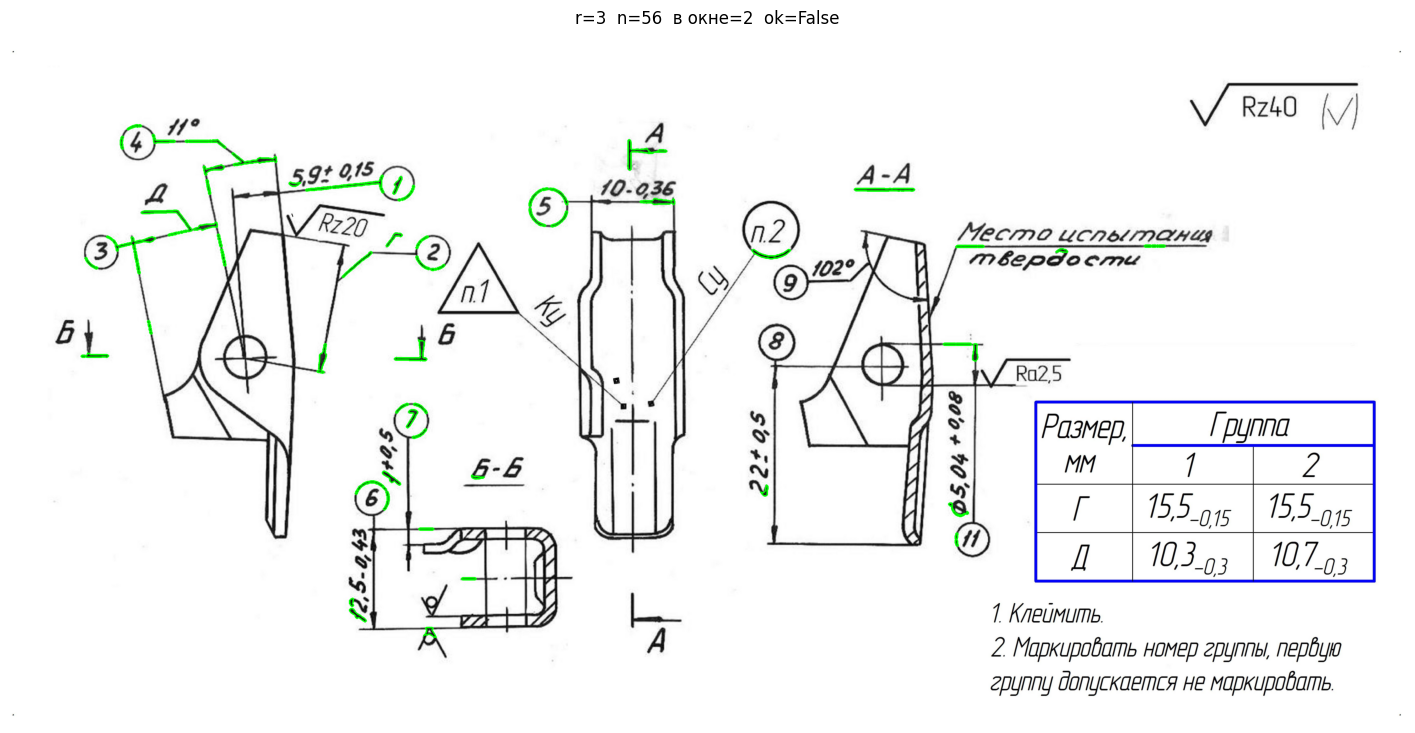

In [1163]:
r = max(3, int(round(0.01 * TARGET_S)))  # = 5 при TARGET_S=60
kern = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2 * r + 1, 2 * r + 1))
s = cv2.morphologyEx(ink, cv2.MORPH_OPEN, kern)
s[mask_work] = 0
c, _ = cv2.findContours(s, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
sel = [x for x in c if lo < cv2.contourArea(x) < hi]
peri = cv2.arcLength(sel[0], True) if sel else 0
approx = cv2.approxPolyDP(sel[0], 0.04 * peri, True) if sel else []
ok = len(approx) == 3 and cv2.isContourConvex(approx) if sel else False

vis = work.copy()
cv2.drawContours(vis, sel, -1, (0, 255, 0), 3)

plt.figure(figsize=(18, 11))
plt.imshow(vis[:, :, ::-1])
plt.axis("off")
plt.title(f"r={r}  n={len(sel)}  в окне={((a > lo) & (a < hi)).sum()}  ok={ok}")
plt.show()


In [1153]:
print(f"s_med={s_med:.1f}  k={k:.3f}  work={work.shape[1]}x{work.shape[0]}")
A = np.array([cv2.contourArea(c) for c in cnts])
print(np.percentile(A, [10, 25, 50, 75, 90, 100]).round(0), f"  окно=[{lo:.0f},{hi:.0f}]")


s_med=92.7  k=0.647  work=4413x2186
[  7213.   8625.  14488.  33493.  43052. 104372.]   окно=[216,1440]


In [1154]:
gray_s = cv2.cvtColor(src, cv2.COLOR_BGR2GRAY)
ink_s = cv2.threshold(gray_s, 0, 255, cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU)[1]
dt_s = cv2.distanceTransform(ink_s, cv2.DIST_L2, 5)

stroke = 2 * np.median(dt_s[(ink_s > 0) & mask])
print(f"штрих={stroke:.2f}  s_med по штриху={10 * stroke:.1f}  s_med по высоте={s_med:.1f}")


штрих=6.00  s_med по штриху=60.0  s_med по высоте=92.7
